In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import plotly.graph_objs as go
import plotly.express as px
import pyarrow as pa

In [2]:
spark_data = pd.read_parquet("../data/processed/south_park.parquet")
simpsons_data = pd.read_parquet("../data/processed/simpsons.parquet")

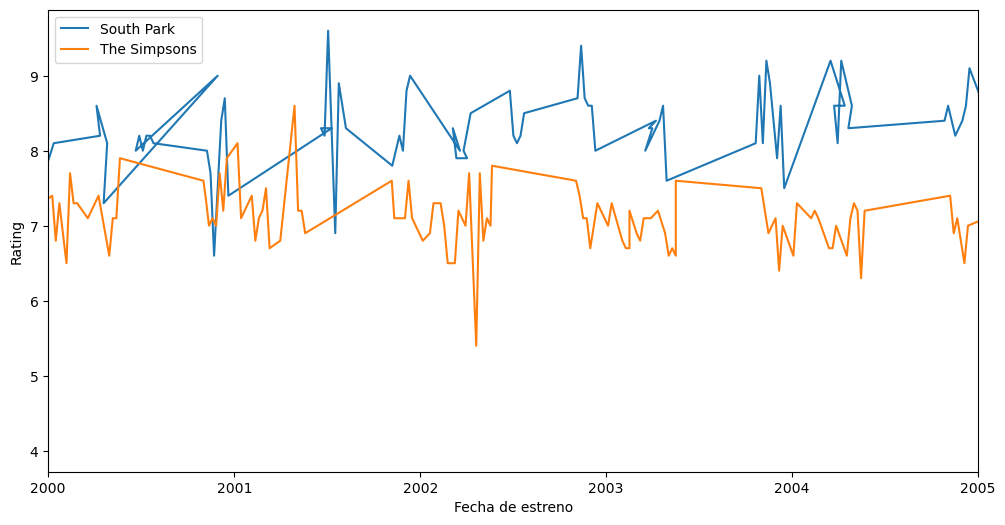

In [3]:
#visualizacion de datos en gráfica
fig, ax = plt.subplots(figsize=(12, 6))

f1 = pd.to_datetime("2000")
f2 = pd.to_datetime("2005")

ax.plot(
    spark_data["fecha_estreno"],
    spark_data["rating"],
    label="South Park"
)

ax.plot(
    simpsons_data["fecha_estreno"],
    simpsons_data["rating"],
    label="The Simpsons"
)

ax.set_xlim(f1, f2)

ax.set_xlabel("Fecha de estreno")
ax.set_ylabel("Rating")
ax.legend()

plt.show()

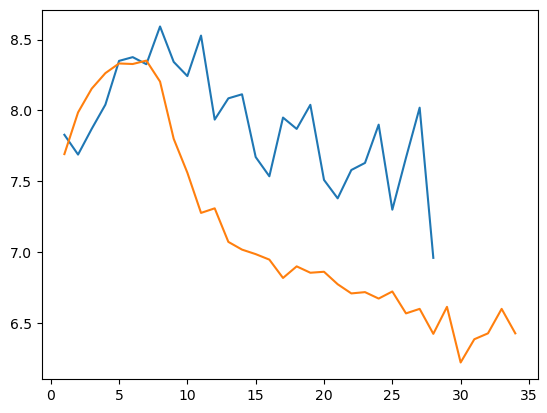

In [4]:
sp_temp = spark_data.groupby("temporada")["rating"].mean()
sim_temp = simpsons_data.groupby("temporada")["rating"].mean()

plt.plot(sp_temp, label="South Park")
plt.plot(sim_temp, label="Simpsons")

In [5]:
#la primera gráfica pero ahora con plotly

import plotly.graph_objects as go
import pandas as pd

f1 = pd.to_datetime("2000-01-01")
f2 = pd.to_datetime("2005-12-31")

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=spark_data["fecha_estreno"],
        y=spark_data["rating"],
        mode="lines",
        name="South Park"
    )
)

fig.add_trace(
    go.Scatter(
        x=simpsons_data["fecha_estreno"],
        y=simpsons_data["rating"],
        mode="lines",
        name="Los Simpsons"
    )
)

fig.update_layout(
    title="Ratings de episodios a lo largo del tiempo",
    xaxis_title="Fecha de estreno",
    yaxis_title="Rating",
    width=1000,
    height=500
)

fig.update_xaxes(
    range=[f1, f2]
)

fig.show()